# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Aryo Dwi Haryanto
- Email: aryodwi122@gmail.com
- Id Dicoding:aryo_dwi_h

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
# Import library untuk manipulasi data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


# Import library untuk Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Mengabaikan warnings agar output lebih rapi
import warnings
warnings.filterwarnings('ignore')

### Menyiapkan data yang akan diguankan

In [2]:
# Load dataset
df = pd.read_csv ('employee_data.csv')

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding

In [3]:
print("Informasi Dataset:")
df.info()
print("\n-----------------------------------\n")

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   in

In [4]:
print("Pengecekan Missing Value:")
print(df.isnull().sum())
print("\n-----------------------------------\n")

Pengecekan Missing Value:
EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalanc

In [5]:
duplicate_count = df.duplicated().sum()
print("Jumlah duplikasi: ", duplicate_count)

Jumlah duplikasi:  0


# Exploratory Data Analysis (EDA)

# EDA UNIVARIATE

# NUMERIK

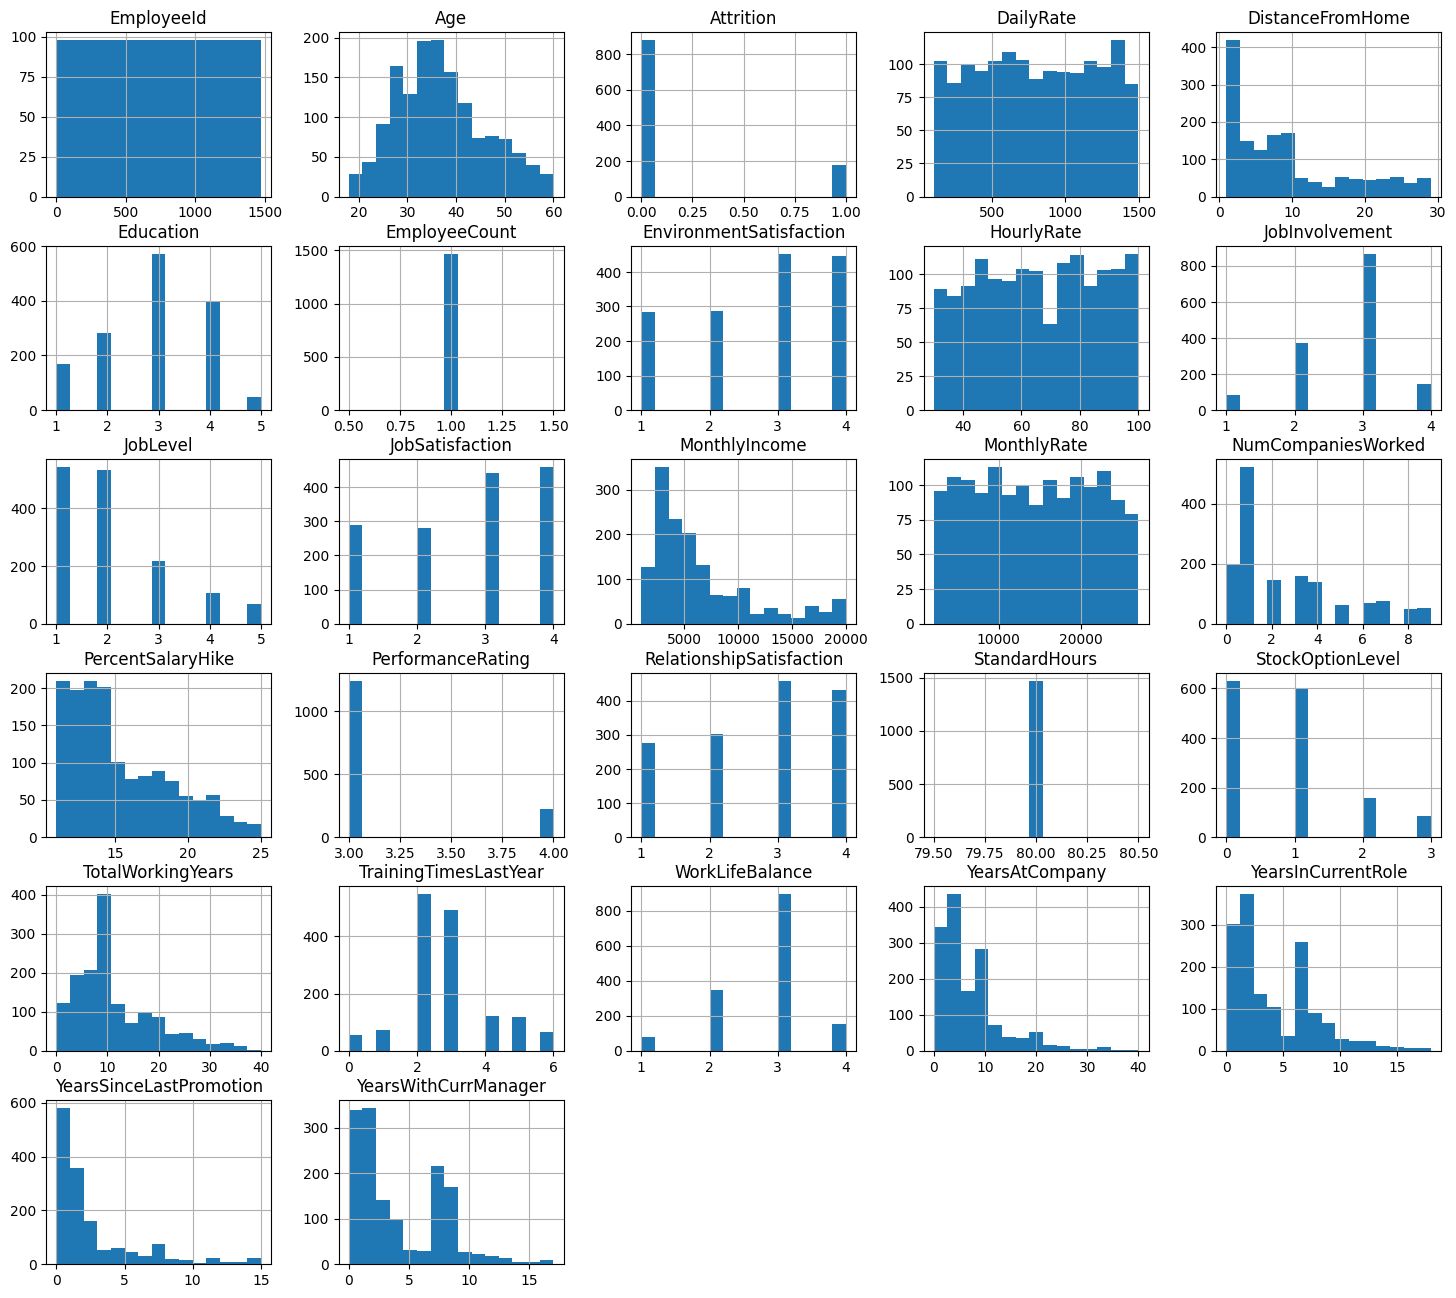

In [6]:
numerical, categorical = [], []

for feature in df.columns:
    if df[feature].dtype != 'object':
        numerical.append(feature)
    else:
        categorical.append(feature)
# Numerical Univariate Analysis
df[numerical].hist(bins=15, figsize=(18, 16))
plt.show()

**Insight:**
* Usia Produktif : Mayoritas karyawan berada di rentang usia 30-40
tahun (puncak distribusi Age). Ini menunjukkan tenaga kerja yang sudah memiliki pengalaman stabil namun masih dalam masa produktif panjang.

* Grafik YearsAtCompany menunjukkan kemiringan tinggi ke kanan (highly skewed). Artinya, perusahaan didominasi oleh karyawan dengan masa kerja pendek (0-10 tahun). Ada indikasi turnover yang perlu diperhatikan atau perusahaan sedang dalam fase ekspansi besar-besaran baru-baru ini.

* Pada grafik YearsSinceLastPromotion, terlihat penumpukan ekstrem di angka 0-2 tahun. Ini berarti sebagian besar karyawan baru saja naik jabatan, ATAU mereka yang sudah lama bekerja justru belum mendapatkan promosi lagi dalam waktu yang lama.

* MonthlyIncome memiliki skewness positif yang sangat kuat. Mayoritas karyawan memiliki gaji di rentang rendah ke menengah ($2.500 - $7.000), sementara hanya segelintir "top talent" atau eksekutif yang mencapai angka di atas $15.000.

* Grafik PercentSalaryHike menunjukkan mayoritas kenaikan gaji berada di angka 11-14%. Sangat sedikit karyawan yang mendapatkan kenaikan di atas 20%, yang biasanya berkorelasi dengan PerformanceRating yang juga didominasi angka 3.


* Variabel seperti EnvironmentSatisfaction, JobSatisfaction, dan RelationshipSatisfaction menunjukkan pola yang mirip: mayoritas memberikan skor 3 dan 4. Ini menandakan budaya kerja secara umum dianggap positif oleh karyawan.

* Grafik YearsWithCurrManager menunjukkan banyak karyawan yang "menempel" pada manajer yang sama dalam waktu yang cukup lama. Hal ini menunjukkan bahwa hubungan interpersonal antara atasan dan bawahan cukup kuat di perusahaan ini.

* Mayoritas karyawan memberikan rating 3 untuk WorkLifeBalance, yang berarti mereka merasa pembagian waktu kerja dan pribadi sudah cukup baik.

* Distribusi DistanceFromHome menunjukkan sebagian besar karyawan tinggal dekat dengan kantor (di bawah 10 km). Karyawan yang tinggal jauh (>20 km) jumlahnya sangat sedikit, dan kelompok kecil ini biasanya lebih rentan untuk melakukan attrition (keluar dari perusahaan).

# KATEGORIK

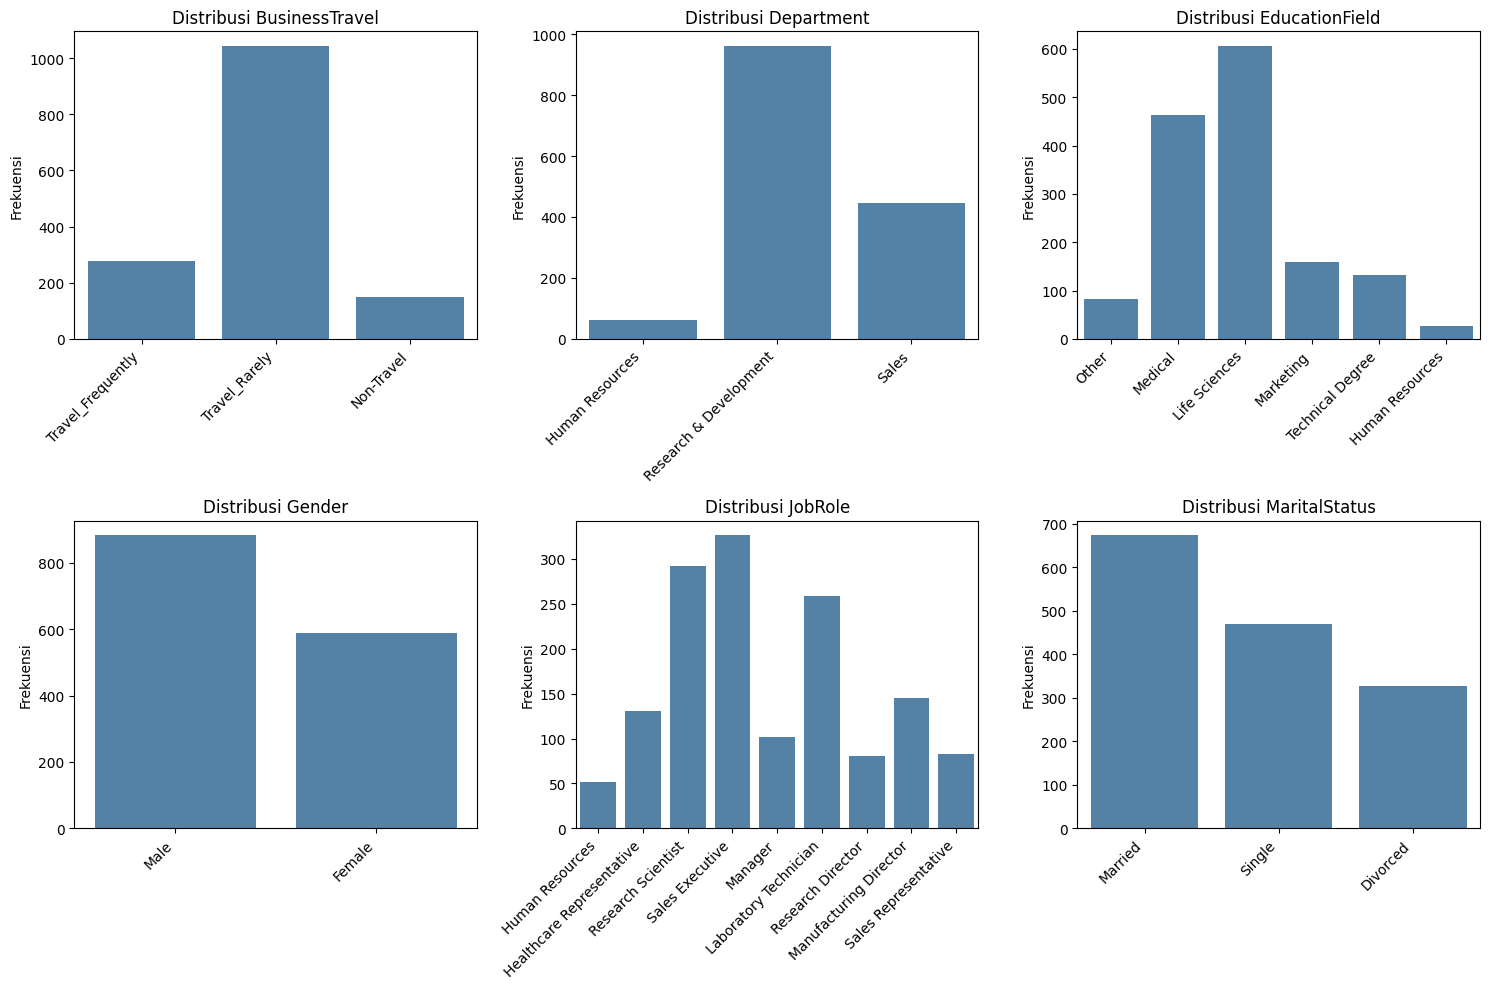

In [7]:
# 1. Menangkap kolom 'object' dan 'category'
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# 2. Memastikan tidak error jika jumlah kolom kurang dari 6
n_cols = min(6, len(cat_cols))

if n_cols > 0:
    plt.figure(figsize=(15, 10))

    for i, col in enumerate(cat_cols[:n_cols], 1):
        plt.subplot(2, 3, i)

        # 3. Menggunakan data=df dan x=col, serta memberi warna solid
        sns.countplot(data=df, x=col, color='steelblue')

        # 4. ha='right' agar ujung teks tepat berada di bawah garis tick sumbu-x
        plt.xticks(rotation=45, ha='right')

        plt.title(f'Distribusi {col}')
        plt.xlabel('') # Menghilangkan judul sumbu-X agar tidak mengulang nama kolom
        plt.ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada kolom kategorikal yang ditemukan di DataFrame ini.")

**Insight:**
* Grafik YearsInCurrentRole dan YearsWithCurrManager menunjukkan pola yang identik, dengan puncak tajam di angka 2 tahun. Ini mengindikasikan bahwa setiap 2 tahun biasanya terjadi perubahan besar, baik itu rotasi jabatan atau pergantian atasan langsung.

* Sama seperti grafik sebelumnya, YearsAtCompany menunjukkan bahwa perusahaan ini sangat bergantung pada karyawan dengan masa kerja 0-5 tahun. Ada tantangan besar dalam mempertahankan karyawan agar bisa mencapai masa kerja "veteran" (di atas 15 tahun).

* Mayoritas karyawan berada di angka 0-1 tahun pada grafik YearsSinceLastPromotion. Ini kabar baik, artinya banyak pergerakan karier yang terjadi baru-baru ini. Namun, waspadai "ekor" distribusi yang mencapai 15 tahun; ada segelintir karyawan yang sudah sangat lama tidak tersentuh promosi.

* StockOptionLevel didominasi oleh level 0 dan 1. Jika perusahaan ingin meningkatkan loyalitas pada level manajerial atau spesialis, meningkatkan akses ke stock options bisa menjadi strategi yang dipertimbangkan.

* Pada grafik TrainingTimesLastYear, mayoritas karyawan menerima 2 hingga 3 kali pelatihan dalam setahun. Ini menunjukkan departemen L&D (Learning & Development) cukup aktif dan perusahaan berinvestasi pada peningkatan skill karyawan.

* WorkLifeBalance berada di posisi yang sehat (mayoritas skor 3). Sangat sedikit karyawan yang merasa terbebani secara ekstrem (skor 1), yang biasanya merupakan prediktor utama orang ingin mengundurkan diri.

* Grafik Attrition menunjukkan bahwa angka 0.0 (Stay) jauh lebih tinggi dibandingkan 1.0 (Resign). Meskipun ada karyawan yang keluar, secara keseluruhan perusahaan masih mampu mempertahankan mayoritas stafnya.

# EDA BIVARIATE

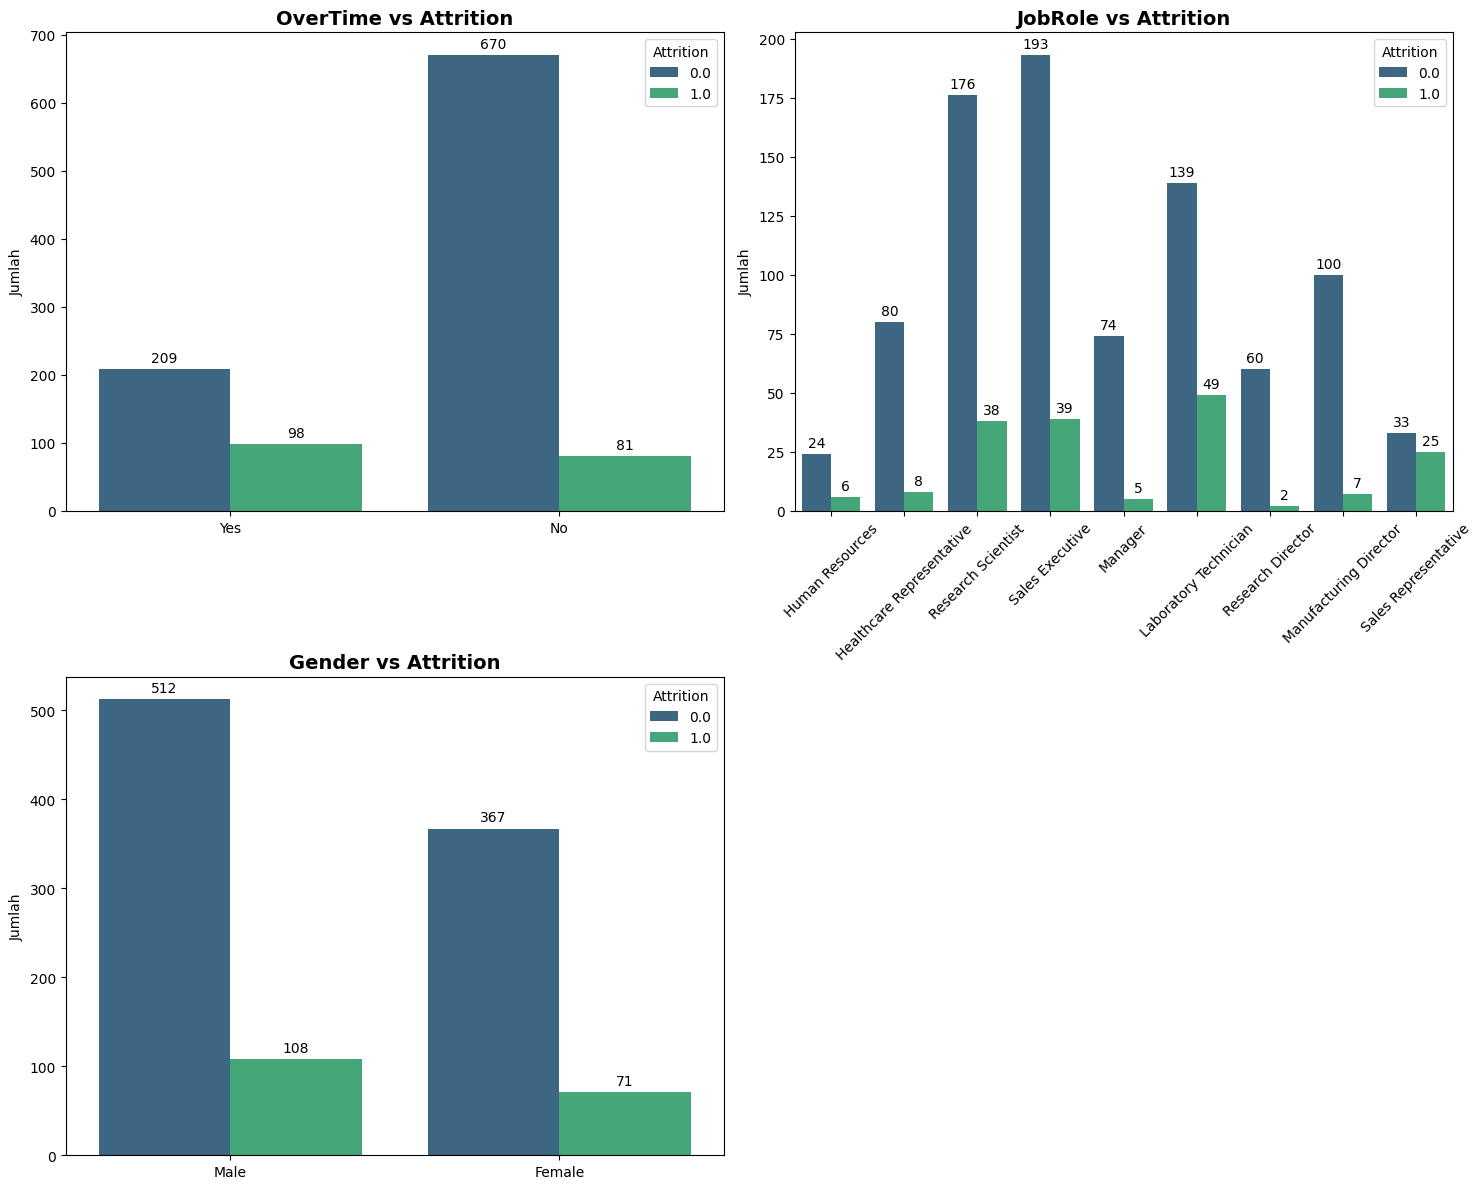

In [8]:
# Attrition vs Kategorikal
# Daftar kolom kategorikal
kolom_kategorikal = ['OverTime', 'JobRole', 'Gender']

# Menggunakan subplots untuk kontrol axis yang lebih terpusat
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten() # Menjadikan array 1D agar mudah di-loop

for i, col in enumerate(kolom_kategorikal):
    # Membuat plot pada axis yang spesifik (ax=axes[i])
    sns.countplot(x=col, hue='Attrition', data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} vs Attrition', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Jumlah')
    axes[i].set_xlabel('') # Menghilangkan label x karena judul sudah jelas

    # 1. Rotasi label sumbu X khusus untuk JobRole agar teks tidak tumpang tindih
    if col == 'JobRole':
        axes[i].tick_params(axis='x', rotation=45)

    # 2. Menambahkan anotasi angka di atas masing-masing bar
    for container in axes[i].containers:
        axes[i].bar_label(container, padding=3)

# 3. Menghapus subplot ke-4 yang kosong (indeks 3)
fig.delaxes(axes[3])

plt.tight_layout()
plt.show()

**Insight:**
* Grafik OverTime adalah yang paling kontras. Karyawan yang sering bekerja lembur (Yes) memiliki proporsi keluar (Attrition) yang jauh lebih tinggi dibandingkan mereka yang tidak.
Lembur yang tidak terkendali adalah prediktor terkuat karyawan akan resign. Ini adalah sinyal bahwa beban kerja mungkin tidak sehat.

* Grafik MaritalStatus menunjukkan bahwa karyawan yang Single memiliki tingkat attrition tertinggi.Karyawan lajang cenderung lebih lincah dan berani mengambil risiko untuk pindah kerja karena beban tanggungan yang lebih sedikit dibandingkan mereka yang sudah menikah atau bercerai.

* Pada grafik JobRole, posisi Sales Representative menunjukkan tingkat keluar yang sangat tinggi secara proporsional. Beban target penjualan yang tinggi atau tekanan di lapangan membuat posisi ini sangat tidak stabil. Sebaliknya, posisi Manager dan Research Director hampir tidak memiliki attrition sama sekali (sangat stabil).

* Karyawan dari latar belakang Technical Degree dan Marketing cenderung lebih sering keluar dibanding bidang Medical atau Life Sciences.

* Karyawan yang masuk kategori Travel_Frequently (sering bepergian) memiliki rasio keluar yang lebih besar daripada mereka yang jarang atau tidak pernah dinas luar. Mobilitas yang terlalu tinggi bisa mengganggu keseimbangan hidup, yang akhirnya berujung pada keputusan untuk mencari pekerjaan yang lebih "stasioner".

* Departemen Sales memiliki rasio perpindahan karyawan yang lebih tinggi dibandingkan Research & Development. Tidak terlihat perbedaan yang sangat signifikan antara Male dan Female, artinya faktor kebijakan internal atau beban kerja jauh lebih berpengaruh daripada masalah gender di perusahaan ini.

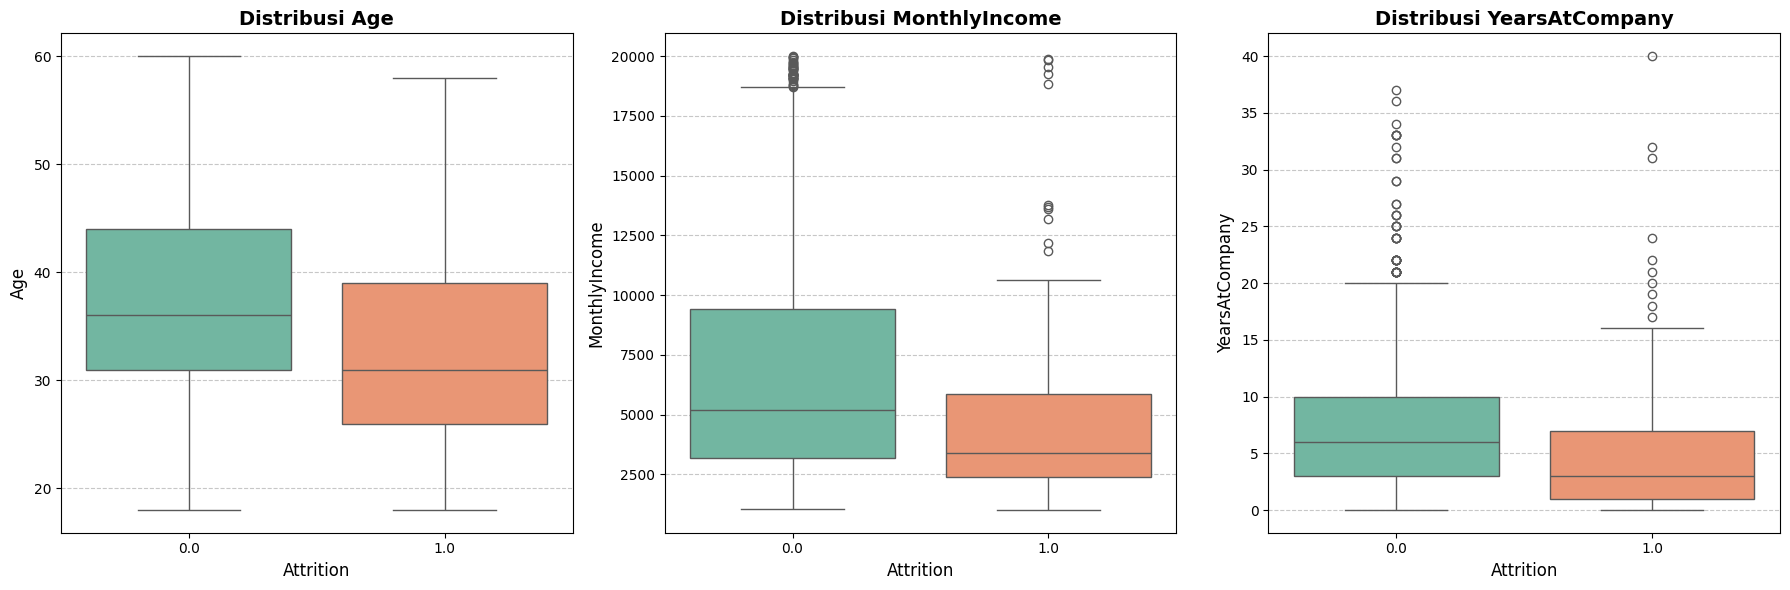

In [9]:
kolom_numerikal = ['Age', 'MonthlyIncome', 'YearsAtCompany']

# Menggunakan grid 1 baris x 3 kolom karena jumlah variabelnya pas 3
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(kolom_numerikal):
    # Menambahkan hue dan palette untuk warna, legend=False agar tidak ada legenda ganda
    sns.boxplot(
        x='Attrition',
        y=col,
        data=df,
        ax=axes[i],
        hue='Attrition',
        palette='Set2',
        legend=False
    )

    # Merapikan judul dan label
    axes[i].set_title(f'Distribusi {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Attrition', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)

    # Menambahkan garis bantu (grid) horizontal agar angka lebih mudah dibaca
    axes[i].yaxis.grid(True, linestyle='--', alpha=0.7)

    # Mengatur background di dalam plot agar garis bantu lebih menonjol (opsional)
    axes[i].set_axisbelow(True)

plt.tight_layout()
plt.show()

**Insight:**
1. Distribusi Age (Usia)
* Median usia karyawan yang keluar (Attrition 1.0) terlihat lebih rendah (sekitar 31 tahun) dibandingkan karyawan yang bertahan (sekitar 36 tahun).

* Karyawan yang bertahan (Attrition 0.0) memiliki rentang usia yang lebih luas hingga usia 60 tahun, sementara mayoritas yang keluar terkonsentrasi di usia yang lebih muda.

* Ada kecenderungan bahwa karyawan di tahap awal karier mereka memiliki tingkat turnover yang lebih tinggi.

2. Distribusi MonthlyIncome (Pendapatan Bulanan)
* Karyawan yang keluar memiliki median pendapatan bulanan yang jauh lebih rendah (sekitar 3.000 - 4.000) dibandingkan mereka yang bertahan (di atas 5.000).
* Terdapat beberapa outlier pada kelompok Attrition 1.0 yang memiliki gaji sangat tinggi (hingga 20.000) namun tetap keluar. Ini menunjukkan bahwa untuk sebagian kecil karyawan, uang bukan satu-satunya alasan mereka berhenti.
* Kelompok yang bertahan memiliki sebaran gaji yang jauh lebih besar ke atas, menunjukkan bahwa kompensasi yang lebih tinggi berkorelasi positif dengan retensi karyawan.

3. Distribusi YearsAtCompany (Lama Bekerja di Perusahaan)
* masa kerja bagi karyawan yang keluar berada di angka yang sangat rendah (sekitar 3 tahun), sedangkan yang bertahan memiliki median sekitar 6 tahun.

* Sebagian besar karyawan yang keluar (kuartil atas) memiliki masa kerja di bawah 10 tahun. Jika karyawan berhasil melewati masa 10 tahun pertama, probabilitas mereka untuk bertahan menjadi jauh lebih tinggi.

*  Meskipun ada beberapa karyawan senior (masa kerja 20-40 tahun) yang keluar sebagai outlier, jumlahnya sangat sedikit dibandingkan mereka yang bertahan di masa kerja tersebut.

# EDA MULTIVARIATE



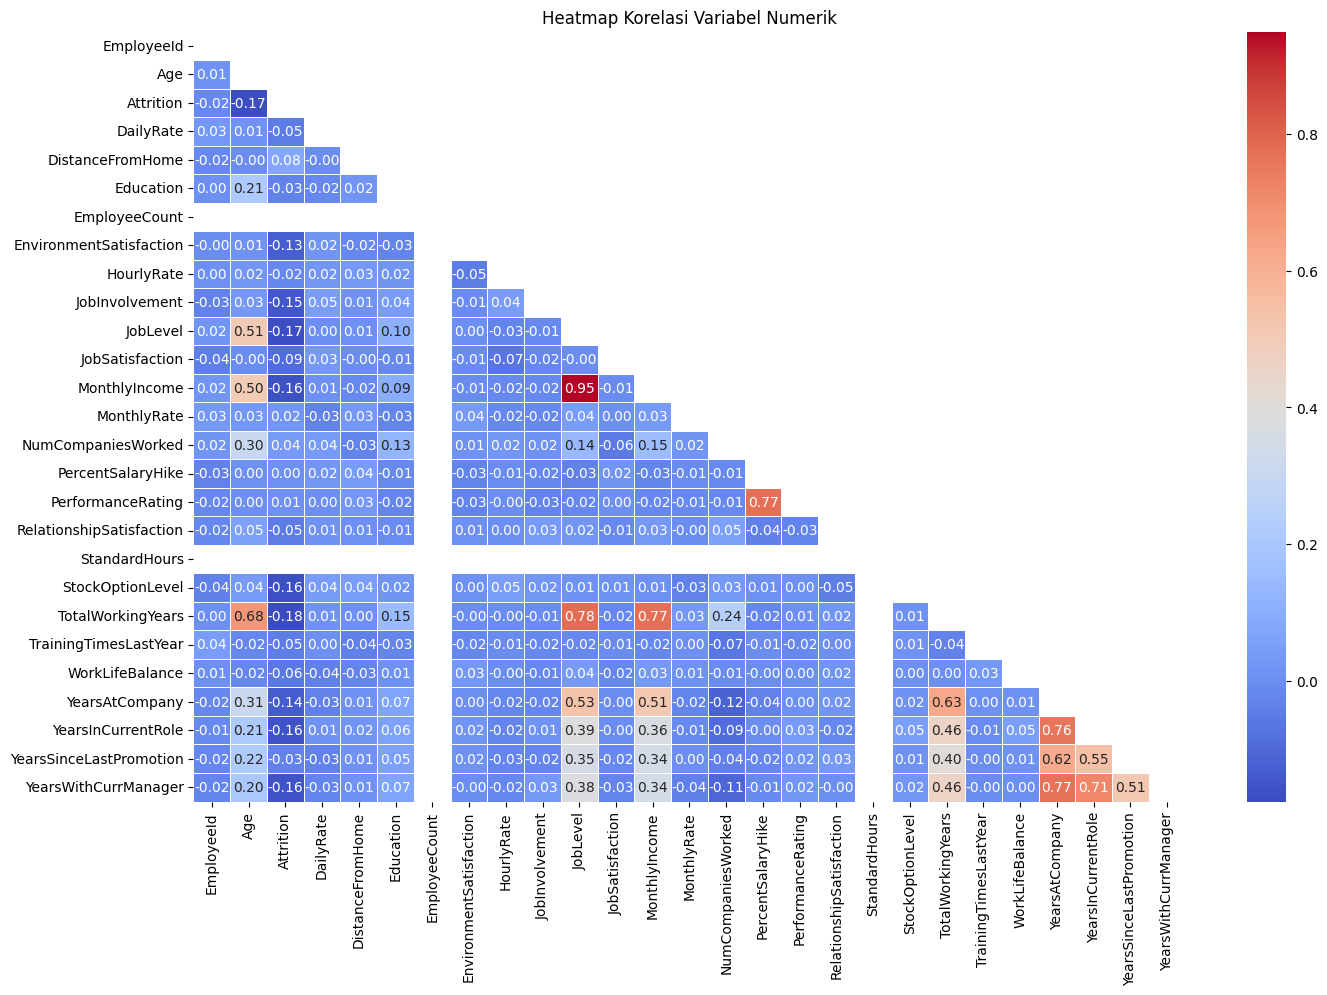

In [10]:
# Korelasi antar variabel numerik
# Ambil korelasi
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Mask untuk segitiga atas
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={"size": 10},
    mask=mask
)

plt.title('Heatmap Korelasi Variabel Numerik')
plt.show()

# Insight Utama
* JobLevel ↔ MonthlyIncome (0.95)
Korelasi sangat kuat → semakin tinggi level jabatan, semakin besar gaji.
Ini menunjukkan struktur organisasi berjalan linear (level = kompensasi).

* JobLevel ↔ TotalWorkingYears (0.79)
Semakin lama pengalaman kerja, semakin tinggi kemungkinan naik jabatan.
Indikasi bahwa promosi berbasis senioritas/pengalaman.

* MonthlyIncome ↔ TotalWorkingYears (0.78)
Pengalaman kerja berbanding lurus dengan peningkatan gaji.
Bisa jadi karena kenaikan berkala atau akumulasi skill.

* PercentSalaryHike ↔ PerformanceRating (0.77)
Karyawan dengan performa tinggi cenderung mendapat kenaikan gaji lebih besar.
Sistem reward berbasis kinerja sudah cukup efektif.

# Insight Struktur Karier
* YearsAtCompany ↔ YearsInCurrentRole (0.76)
Karyawan yang lama di perusahaan cenderung lama juga di posisi yang sama.
Potensi indikasi lambatnya rotasi/promosi internal.

* YearsAtCompany ↔ YearsWithCurrManager (0.76)
Lama bekerja berbanding lurus dengan lamanya bekerja dengan atasan yang sama.
Bisa menunjukkan stabilitas tim, tapi juga potensi stagnasi.

* YearsInCurrentRole ↔ YearsWithCurrManager (0.72)
Semakin lama di posisi, semakin lama juga dengan manajer yang sama.
Hubungan kerja relatif stabil (low turnover antar tim).

# Insight Demografi & Pengalaman
* Age ↔ TotalWorkingYears (0.69)
Usia meningkat → pengalaman kerja meningkat (logis dan expected).
Validasi bahwa data cukup konsisten.

* TotalWorkingYears ↔ YearsAtCompany (0.63)
Karyawan dengan pengalaman tinggi cenderung lebih lama bertahan di perusahaan.
Bisa menunjukkan retensi baik pada karyawan senior.

# Insight Struktur Organisasi
* Department ↔ JobRole (0.65)
Role pekerjaan sangat bergantung pada departemen.
Struktur organisasi cukup jelas dan tidak banyak overlap antar fungsi.

# Insight Utama Terkait Attrition (Resign)
* Attrition ↔ TotalWorkingYears (-0.18)
Semakin tinggi pengalaman kerja, semakin kecil kemungkinan karyawan resign.
Karyawan senior cenderung lebih stabil dan loyal.

* Attrition ↔ Age (-0.17)
Karyawan yang lebih muda lebih berisiko resign.
Biasanya karena masih fase eksplorasi karier.

* Attrition ↔ JobLevel (-0.17)
Level jabatan rendah lebih rentan resign.
Posisi entry-level cenderung memiliki turnover tinggi.

* Attrition ↔ MonthlyIncome (-0.16)
Gaji rendah meningkatkan kemungkinan resign.


* Attrition ↔ StockOptionLevel (-0.16)
Karyawan tanpa atau dengan sedikit benefit saham lebih cenderung resign.
Benefit jangka panjang efektif untuk retensi.

# Insight Lingkungan Kerja
* Attrition ↔ YearsInCurrentRole (-0.16)
Semakin lama di posisi, semakin kecil kemungkinan resign.
Bisa karena sudah nyaman atau sulit berpindah.

* Attrition ↔ YearsWithCurrManager (-0.16)
Hubungan lama dengan atasan menurunkan risiko resign.
Indikasi pentingnya stabilitas hubungan kerja.

* Attrition ↔ JobInvolvement (-0.15)
Keterlibatan kerja rendah → lebih tinggi kemungkinan resign.
Engagement jadi faktor penting retensi.

# Insight Karier & Struktur
* JobRole ↔ TotalWorkingYears (-0.17)
Beberapa role tertentu cenderung diisi oleh karyawan dengan pengalaman lebih rendah.
Bisa menunjukkan adanya role entry-level spesifik.

# Insight Menarik (Perlu Perhatian Khusus)
* MaritalStatus ↔ StockOptionLevel (-0.68)
Korelasi negatif cukup kuat.
Kemungkinan:
Karyawan dengan status tertentu (misalnya single) lebih banyak mendapat stock option rendah/tinggi.

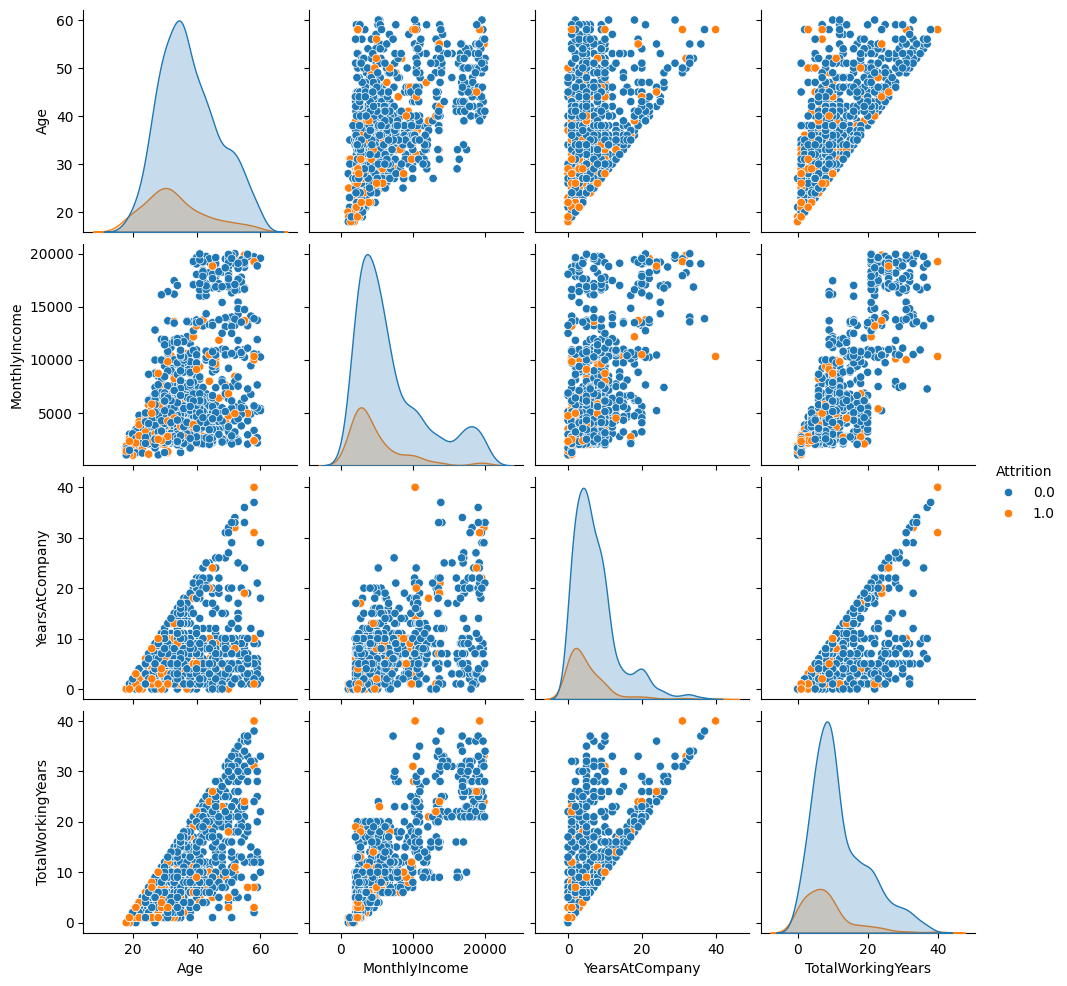

In [11]:
# Pairplot
sns.pairplot(df[['Age','MonthlyIncome','YearsAtCompany','TotalWorkingYears','Attrition']], hue='Attrition')
plt.show()

**Insight:**
1. Tren Attrition pada Usia dan Pendapatan
* Karyawan Muda Lebih Rentan Resign: Pada grafik distribusi Age, terlihat bahwa proporsi karyawan yang keluar (Attrition = 1.0, warna oranye) lebih tinggi pada rentang usia muda (sekitar 20–35 tahun). Seiring bertambahnya usia, kepadatan titik oranye semakin berkurang.

* Pendapatan Rendah vs Attrition: Grafik MonthlyIncome menunjukkan bahwa attrition terkonsentrasi pada karyawan dengan gaji rendah (di bawah 5.000). Sangat sedikit karyawan dengan gaji tinggi (di atas 15.000) yang memilih untuk keluar.

2. Hubungan Antar Variabel (Korelasi Positif)
* Total Working Years & Age: Terdapat korelasi positif yang kuat (membentuk garis diagonal). Hal ini logis: semakin tua usia seseorang, semakin besar peluang mereka memiliki total masa kerja yang panjang.

* Monthly Income & Total Working Years: Terlihat tren di mana pendapatan bulanan cenderung meningkat seiring dengan bertambahnya total pengalaman kerja. Namun, ada banyak variasi (beberapa orang dengan pengalaman tinggi tetap memiliki gaji menengah).

* Years At Company & Total Working Years: Terdapat batas bawah yang jelas (karena masa kerja di perusahaan saat ini tidak mungkin melebihi total masa kerja seumur hidup).

3. Loyalitas dan Masa Kerja
* Risiko pada Tahun Awal: Pada grafik YearsAtCompany, titik-titik oranye sangat padat di angka 0–5 tahun. Ini mengindikasikan bahwa pergantian karyawan paling sering terjadi pada masa-masa awal mereka bergabung dengan perusahaan.

* Stabilitas Karyawan Senior: Karyawan yang sudah bekerja di atas 10 tahun di perusahaan yang sama cenderung jauh lebih stabil dan jarang melakukan attrition.

4. Batasan Karir dan Gaji
* Plafon Gaji: Pada grafik MonthlyIncome vs Age, terlihat beberapa kluster horizontal. Ini menunjukkan adanya struktur job level tertentu di mana gaji mentok pada angka tertentu meskipun usia terus bertambah.

In [12]:
# Attrition Rate (%)
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print(attrition_rate)

Attrition
0.0    83.081285
1.0    16.918715
Name: proportion, dtype: float64


**Insight:**
* Attrition rate untuk yang tetap (Stay) sebanyak 83% sedangkan yang pergi (Resign) 16%

In [13]:
# Rata-rata berdasarkan Attrition
df.groupby('Attrition')[['Age','MonthlyIncome','YearsAtCompany']].mean()

,Age,MonthlyIncome,YearsAtCompany
Attrition,,,
0.0,37.786121,6982.928328,7.447099
1.0,33.469274,4872.938547,5.189944


**Insight:**
* untuk yang stay rata rata umur 37 tahun dengan pendapatan 7 juta dan lama bekerja selama 7 tahun

* untuk yang resign umur nya rata rata 33 tahun dengan pendapatan 4,8 juta dan lama bekerja selama 5 tahun

In [14]:
# Crosstab
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

Attrition,0.0,1.0
OverTime,,
No,89.214381,10.785619
Yes,68.078176,31.921824


**Insight:**
* Hasil crosstab menunjukkan Karyawan yang melakukan lembur (OverTime = Yes) memiliki tingkat attrition sebesar 31.92%, jauh lebih tinggi dibandingkan karyawan yang tidak lembur yaitu 10.79%.

# Menangani data dengan SMOTE

In [26]:
# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Melakukan Oversampling pada data training
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Jumlah data sebelum SMOTE: {np.bincount(y_train)}")
print(f"Jumlah data setelah SMOTE: {np.bincount(y_train_res)}")

Jumlah data sebelum SMOTE: [703 143]
Jumlah data setelah SMOTE: [703 703]


**Insight:**
Berdasarkan EDA, ditemukan bahwa kelas target (Attrition) sangat timpang (mayoritas karyawan bertahan). Jika langsung dimodelkan, model akan cenderung bias dan gagal mendeteksi karyawan yang akan resign.

Penggunaan SMOTE dilakukan untuk menyeimbangkan jumlah sampel kelas minoritas secara sintetis. Hal ini bertujuan untuk meningkatkan nilai Recall, agar model lebih sensitif dalam mengidentifikasi potensi karyawan yang akan keluar.

## Data Preparation / Preprocessing

In [27]:
# a. Menangani Missing Value pada target 'Attrition'
# Karena Attrition adalah target prediksi, kita akan drop baris yang Attrition-nya kosong
df = df.dropna(subset=['Attrition'])

# Memastikan target menjadi integer (0 dan 1)
df['Attrition'] = df['Attrition'].astype(int)

# Menangani missing value di kolom lain (jika ada)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)


In [28]:
# b. Menghapus kolom yang tidak relevan untuk pemodelan
# Contoh: Kolom 'EmployeeId' tidak berpola, sementara 'EmployeeCount', 'Over18', dan 'StandardHours' biasanya nilainya cuma satu macam
cols_to_drop = ['EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

**Insight:**
Kolom seperti EmployeeCount, Over18, StandardHours, dan EmployeeNumber dihapus karena tidak memiliki variasi nilai (konstan) atau hanya bersifat sebagai ID unik.

Menghapus kolom yang tidak informatif ini membantu model agar lebih efisien dan mencegah noise yang tidak perlu dalam proses perhitungan algoritma.



In [29]:
# c. Encoding fitur kategorikal menjadi numerik
categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

**Insight:** Karena mesin algoritma (Random Forest) hanya dapat memproses data numerik, variabel kategorikal seperti BusinessTravel, Department, dan EducationField dikonversi menjadi angka.

Langkah ini memastikan semua informasi tekstual dari data HR dapat dipetakan ke dalam ruang vektor untuk proses komputasi.

In [30]:
# d. Memisahkan fitur (X) dan target (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [31]:
# e. Membagi data menjadi Train (80%) dan Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
# f. Melakukan Standardisasi (Scaling) agar performa model lebih baik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data berhasil disiapkan dan siap dimodelkan!")

Data berhasil disiapkan dan siap dimodelkan!


**Insight:**
Data dibagi menjadi 80% untuk training dan 20% untuk testing untuk memastikan model dapat diuji pada data yang belum pernah dilihat sebelumnya (unseen data).

StandardScaler diterapkan untuk menyamakan skala seluruh fitur numerik (misalnya Age yang puluhan dan MonthlyIncome yang ribuan). Tanpa scaling, fitur dengan angka besar akan mendominasi hasil perhitungan bobot model secara tidak adil.

## Modeling

In [33]:
# Membuat model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Melatih model dengan data yang sudah di-SMOTE
rf_model.fit(X_train_res, y_train_res)

# Melakukan prediksi
y_pred = rf_model.predict(X_test_scaled)

print("Model selesai dilatih!")


Model selesai dilatih!


## Evaluation

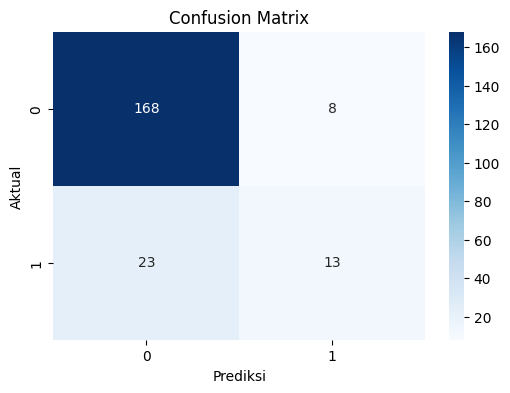

In [34]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

**Insight:**
* Insight Performa Model
Akurasi cukup tinggi (~88%)
(168 + 13) / total data
Model cukup baik secara umum dalam klasifikasi.

* Model sangat baik mendeteksi “tidak attrition”
TN jauh lebih besar → model kuat di kelas mayoritas.

* Cocok untuk memastikan siapa yang kemungkinan tetap bertahan.

* Deteksi “attrition” masih lemah
TP (13) relatif kecil dibanding FN (23).

* Artinya banyak karyawan yang sebenarnya resign tapi tidak terdeteksi.

* Insight Error (Kesalahan Model)
* False Negative cukup tinggi (23 kasus)
Ini masalah utama.

* Model gagal mengidentifikasi karyawan yang berpotensi resign.
Dalam konteks HR → ini berisiko karena kehilangan karyawan tanpa antisipasi.

* False Positive rendah (8 kasus)
Model jarang salah memprediksi orang akan resign.
Artinya intervensi HR tidak terlalu banyak “salah sasaran”.

In [35]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.92       176
           1       0.62      0.36      0.46        36

    accuracy                           0.85       212
   macro avg       0.75      0.66      0.69       212
weighted avg       0.84      0.85      0.84       212



In [36]:
# Accuracy Score
print(f"Akurasi Model: {accuracy_score(y_test, y_pred):.2f}")

Akurasi Model: 0.85


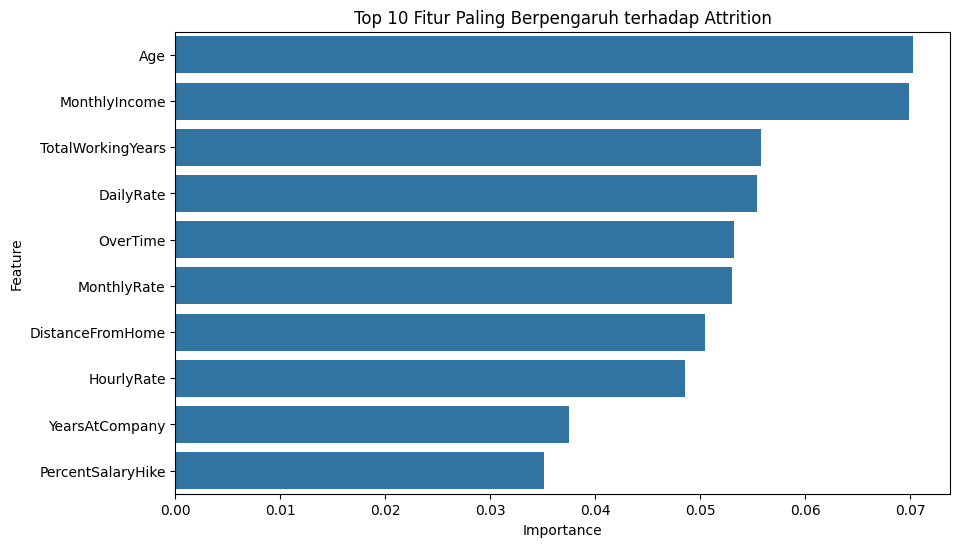

In [37]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X, y)
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10)
)
plt.title('Top 10 Fitur Paling Berpengaruh terhadap Attrition')
plt.show()

**Insight:**
* Ada 10 fitur paling berpengaruh terhadap attrition

* Usia (Age) dan Gaji Bulanan (MonthlyIncome) adalah faktor paling kritis. Karyawan di fase umur tertentu atau dengan standar gaji rendah paling rentan keluar.

* Stabilitas & Pengalaman: Total Masa Kerja sangat berpengaruh; pengalaman profesional secara umum lebih menentukan dibanding masa kerja di perusahaan saat ini.

* Keseimbangan Hidup: Faktor Lembur (OverTime) dan Jarak Rumah (DistanceFromHome) masuk dalam 10 besar, menunjukkan beban kerja fisik dan durasi komuter memicu pengunduran diri.

* Struktur Upah: Bukan hanya gaji pokok, tapi skema upah (Daily/Hourly Rate) sangat diperhatikan oleh karyawan.

* Apresiasi Tambahan: Kenaikan Gaji (Salary Hike) memiliki pengaruh paling rendah di antara 10 besar, artinya kenaikan persentase kecil tidak efektif jika gaji dasarnya sudah tidak kompetitif.

In [38]:
# 5. Deployment (Menyimpan Model)
# Menyimpan model dan scaler untuk digunakan di aplikasi lokal
model = RandomForestClassifier(random_state=42)
joblib.dump(model, 'model_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("File model_rf.pkl dan scaler.pkl berhasil disimpan!")

File model_rf.pkl dan scaler.pkl berhasil disimpan!


In [39]:
# Mapping label
df['Attrition_Label'] = df['Attrition'].map({0: 'Stay', 1: 'Resign'})

# Simpan ke CSV
df.to_csv('clean_hr_data.csv', index=False, encoding='utf-8')

print("File berhasil disimpan!")

File berhasil disimpan!


## Kesimpulan & Rekomendasi
* **Kesimpulan:**

* Attrition dipengaruhi oleh faktor pekerjaan dan kompensasi
Variabel seperti MonthlyIncome, JobLevel, dan StockOptionLevel memiliki korelasi negatif dengan attrition, yang berarti semakin tinggi kompensasi dan level jabatan, semakin kecil kemungkinan karyawan keluar.

* Pengalaman dan stabilitas kerja berperan penting
YearsInCurrentRole, YearsWithCurrManager, dan TotalWorkingYears juga berkorelasi negatif dengan attrition. Karyawan yang lebih lama bekerja cenderung lebih loyal.

* Keterlibatan kerja (Job Involvement) memengaruhi retensi
Semakin tinggi keterlibatan karyawan, semakin rendah tingkat attrition.

* OverTime meningkatkan risiko attrition
Karyawan yang sering lembur memiliki persentase attrition yang jauh lebih tinggi dibanding yang tidak lembur, menunjukkan potensi burnout.

* Tidak semua variabel memiliki pengaruh kuat
Beberapa variabel hanya memiliki korelasi lemah, sehingga tidak menjadi faktor utama dalam keputusan karyawan untuk keluar.

* **Rekomendasi:**
1. Optimalkan sistem kompensasi dan benefit
* Tingkatkan gaji secara kompetitif
* Berikan insentif seperti bonus atau stock option
* Fokus pada karyawan dengan risiko tinggi keluar

2. Kurangi beban kerja berlebih (OverTime)
* Evaluasi distribusi pekerjaan
* Terapkan manajemen workload yang lebih seimbang
* Tambahkan tenaga kerja jika diperlukan

3. Tingkatkan keterlibatan karyawan (engagement)
* Program penghargaan dan apresiasi
* Libatkan karyawan dalam pengambilan keputusan
* Bangun budaya kerja yang positif

4. Perkuat hubungan atasan–bawahan
* Training leadership untuk manajer
* Monitoring hubungan kerja di tiap divisi
* Feedback rutin antara karyawan dan atasan

5. Fokus pada retensi karyawan baru
* Program onboarding yang lebih baik
* Pendampingan (mentoring)
* Career path yang jelas sejak awal

6. Gunakan model prediktif untuk deteksi dini
* Manfaatkan model machine learning (seperti Random Forest yang kamu buat)
* Identifikasi karyawan dengan risiko attrition tinggi
* Lakukan intervensi lebih awal
